In [ ]:
!sudo apt install tesseract-ocr
!pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  tesseract-ocr-eng tesseract-ocr-osd
The following NEW packages will be installed:
  tesseract-ocr tesseract-ocr-eng tesseract-ocr-osd
0 upgraded, 3 newly installed, 0 to remove and 49 not upgraded.
Need to get 4,816 kB of archives.
After this operation, 15.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-eng all 1:4.00~git30-7274cfa-1.1 [1,591 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-osd all 1:4.00~git30-7274cfa-1.1 [2,990 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr amd64 4.1.1-2.1build1 [236 kB]
Fetched 4,816 kB in 3s (1,747 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debc

In [ ]:
import pytesseract
print(pytesseract.get_tesseract_version())

4.1.1


In [ ]:
from PIL import Image
import pytesseract

def extract_text(image_path):
    with Image.open(image_path) as img:
        # Use pytesseract to do OCR on the image
        text = pytesseract.image_to_string(img, lang='eng')
        print(text)

In [ ]:
extract_text('text.png')

FileNotFoundError: [Errno 2] No such file or directory: '/content/text.png'

In [7]:
from easy_paddle_ocr import TextRecognizer
import time
import cv2

text_recognizer = TextRecognizer()

image1 = cv2.imread('noplate.png')
image2 = cv2.imread('noplate2.png')

prediction1 = text_recognizer.read(image1)
prediction2 = text_recognizer.read(image2)

print(prediction1)
print(prediction2)

ModuleNotFoundError: No module named 'easy_paddle_ocr'

In [9]:
import cv2
from ultralytics import YOLO

ModuleNotFoundError: No module named 'ultralytics'

In [ ]:
# Import Libraries
import os
import gc
import shutil
import cv2
import numpy as np
import pandas as pd
from tqdm import tqdm
tqdm.pandas()
import warnings
warnings.filterwarnings("ignore")

import xml.etree.ElementTree as xet

In [ ]:
!git clone https://github.com/ultralytics/ultralytics

!pip install ultralytics
!pip install -U ray[tune]

Cloning into 'ultralytics'...
remote: Enumerating objects: 46209, done.
remote: Counting objects: 100% (402/402), done.
remote: Compressing objects: 100% (295/295), done.
remote: Total 46209 (delta 235), reused 204 (delta 107), pack-reused 45807 (from 1)
Receiving objects: 100% (46209/46209), 38.37 MiB | 25.90 MiB/s, done.
Resolving deltas: 100% (34403/34403), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.4/887.4 kB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.3/66.3 MB 12.2 MB/s eta 0:00:00


In [ ]:
%%writefile /content/ultralytics/custom_dataset.yaml


train: /content/datasets/train
val: /content/datasets/val
test: /content/datasets/test

nc: 1

names: [
    'license_plate'
]

Writing /content/ultralytics/custom_dataset.yaml


In [ ]:
%%writefile /content/config.yaml

path: /content/dataset
train: images
val: images

nc: 1

names: [
'license_plate'
]

Overwriting /content/config.yaml


In [ ]:
%%writefile /content/drive/MyDrive/Internship-Infosys/YOLOtraining/dataset/config.yaml

path: /content/dataset
train: images
# val: images

nc: 1

names: [
'license_plate'
]

Overwriting /content/drive/MyDrive/Internship-Infosys/YOLOtraining/dataset/config.yaml


In [ ]:
# dataset
#   images
#     train
#     test
#     val
#   labels
#     train
#     test
#     val

In [ ]:
!wandb disabled

!yolo train model=yolov8n.pt data="/content/config.yaml" epochs=10 verbose=True batch=32

W&B disabled.
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
100% 6.25M/6.25M [00:00<00:00, 253MB/s]
Ultralytics 8.3.34 🚀 Python-3.10.12 torch-2.5.1+cu121 CPU (Intel Xeon 2.20GHz)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=/content/config.yaml, epochs=10, time=None, patience=100, batch=32, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, sa

In [ ]:
# # Get Bounding Box Predictions
from ultralytics import YOLO

path = "/content/drive/MyDrive/Internship-Infosys/YOLOtraining/dataset/datasets/test/af608b5e-07d6-4bcf-84d0-f0cba9e54e12___Skoda-Superb-Rear-Profile.jpg.jpeg"
yolo_model = YOLO('/content/drive/MyDrive/Internship-Infosys/trained model for testing purpose/best.pt')
bbox_results = yolo_model.predict(path, verbose=False)

In [ ]:
all_box_list = []
all_conf_list = []


for bbox_result in bbox_results:
    boxes = bbox_result.boxes
    box_list = []
    conf_list = []
    for box in boxes:
        box_data = box.data[0][:4]
        box_data = [int(x) for x in box_data]
        conf = round(float(box.conf), 2)
        if(conf>=0.5):
            box_list.append(box_data)
            conf_list.append(conf)

    all_box_list.append(box_list)
    all_conf_list.append(conf_list)

In [ ]:
all_conf_list

[[0.89]]

In [ ]:
# for i in bbox_results:
#   print(i.boxes)

print(all_box_list[0])
print(all_conf_list)


# for i, box in enumerate(boxes):
#   print(i, box)

[[237, 185, 348, 211]]
[[0.89]]


In [ ]:
ori_path = path
print(ori_path)
ori_image = cv2.imread(ori_path)
ori_image = cv2.cvtColor(ori_image, cv2.COLOR_BGR2RGB)

/content/drive/MyDrive/Internship-Infosys/YOLOtraining/dataset/datasets/test/af608b5e-07d6-4bcf-84d0-f0cba9e54e12___Skoda-Superb-Rear-Profile.jpg.jpeg


In [ ]:
from ultralytics.utils.plotting import Annotator


annotator = Annotator(ori_image)
boxes = all_box_list
confs = all_conf_list

In [ ]:
for i in all_box_list[0]:
  print(i)

[237, 185, 348, 211]


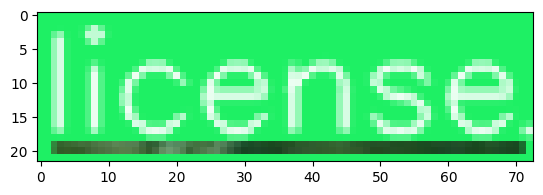

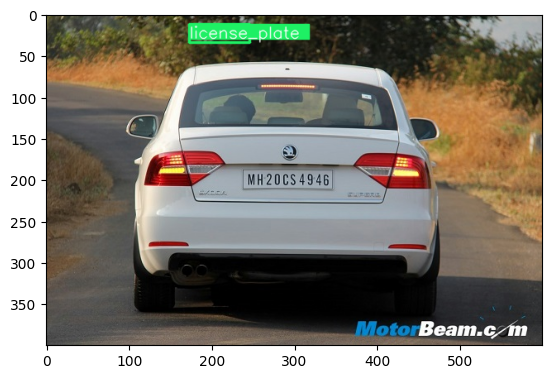

In [ ]:
import matplotlib.pyplot as plt

# for i, box in enumerate(boxes):
#   print(i)
box = [173, 12, 246, 34]
confs = 0.120
annotator.box_label(box=box, label="license_plate ", color=(30, 240, 100))

# Get Plate Object
x1, y1, x2, y2 = box
x1, y1, x2, y2 = int(x1), int(y1), int(x2), int(y2)
roi = ori_image[y1:y2, x1:x2]
plt.imshow(roi)
plt.show()

# Show Image
frame = annotator.result()
plt.imshow(frame)
plt.show()

In [ ]:
print(all_box_list)

[[[237, 185, 348, 211]]]


In [ ]:
all_conf_list

[[0.89]]